# 0. At a glance: the results in euros

The other notebooks derive each result step by step, with the methods and their caveats. This
one restates the main results as concrete examples. Unless stated otherwise, amounts are in
**today's money**: corrected for inflation, so that €100 buys what €100 buys today.

| Term | Meaning |
|---|---|
| Volatility | The typical yearly swing. At 12%, the return lands within 12 points of its average in about two years out of three. |
| Drawdown | The fall from the previous high. €10,000 falling to €4,750 is a 52% drawdown. |
| Correlation | Whether two assets move together: +1 always together, 0 unrelated, -1 always opposite. |
| Sigma | The typical size of a move. A 5-sigma day is five times larger than a typical day. |
| Monte Carlo | Simulating thousands of possible market histories to see the range of outcomes. |

In [1]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from investor_toolkit.plotting import apply_style

warnings.filterwarnings("ignore", category=FutureWarning)
apply_style()
pd.set_option("display.precision", 3)
pd.set_option("display.width", 120)
FIGURES = "../docs/figures"

from scipy import stats

from investor_toolkit import backtest as bt
from investor_toolkit import montecarlo as mc
from investor_toolkit import proxies, risk, universe
from investor_toolkit import returns as rt
from investor_toolkit.plotting import INK, INK_MUTED, INK_SECONDARY, SERIES
from investor_toolkit.tax import GermanTax, blended_partial_exemption

long = proxies.long_history()
balanced = 0.6 * long["world_equity"] + 0.4 * long["bund_10y"]
TAX_60_40 = GermanTax(partial_exemption=blended_partial_exemption(0.6))

## 1. One savings plan, 100 futures

Save €500 a month for 30 years in a portfolio of 60% world stocks and 40% German government
bonds. The monthly amount rises with inflation, so the total paid in is €180,000 in today's
money. Fund costs are 0.2% a year, and German tax is paid along the way and on the final sale.

The simulation builds 10,000 possible 30-year histories from real months since 1999. Each dot
below is one of 100 representative outcomes, one per percentile, showing what the saver keeps
after selling everything and paying the tax.

paid in                           180000.0
median before selling             321308.0
median after tax on the sale      288535.0
worst of 100                      128710.0
best of 100                       645354.0
futures below paid in (of 100)         7.0
dtype: float64

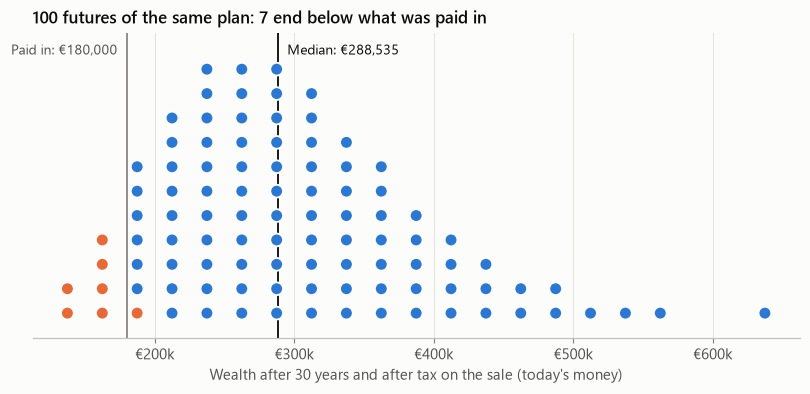

In [2]:
plan = mc.SavingsPlan(
    monthly_contribution=500, accumulation_years=30, annual_fee=0.002, tax=TAX_60_40
)
result = mc.simulate(
    mc.Bootstrap(balanced, long["inflation"], mean_block=12), plan, n_paths=10_000, seed=1
)
before_sale = result.wealth_at_retirement()
after_sale = result.terminal(after_tax=True)
futures = np.quantile(after_sale, (np.arange(100) + 0.5) / 100)
paid_in = 500 * 12 * 30

bin_width = 25_000
bins = np.floor(futures / bin_width).astype(int)
heights = np.array([np.sum(bins[:i] == b) for i, b in enumerate(bins)])
below = futures < paid_in

fig, ax = plt.subplots(figsize=(9, 3.6))
ax.scatter(
    (bins + 0.5) * bin_width,
    heights + 1,
    s=70,
    color=np.where(below, SERIES[1], SERIES[0]),
    edgecolor="white",
    linewidth=1.2,
    zorder=3,
)
ax.axvline(paid_in, color=INK_MUTED, linewidth=1.2)
ax.axvline(np.median(after_sale), color=INK, linewidth=1.2)
ax.annotate(
    f"Paid in: €{paid_in:,.0f}",
    (paid_in, heights.max() + 1.6),
    xytext=(-6, 0),
    textcoords="offset points",
    ha="right",
    color=INK_SECONDARY,
    fontsize=9,
)
ax.annotate(
    f"Median: €{np.median(after_sale):,.0f}",
    (np.median(after_sale), heights.max() + 1.6),
    xytext=(6, 0),
    textcoords="offset points",
    color=INK,
    fontsize=9,
)
ax.set_ylim(0, heights.max() + 2.5)
ax.set_yticks([])
ax.grid(axis="y", visible=False)
ax.spines["left"].set_visible(False)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"€{v / 1000:,.0f}k"))
ax.set_xlabel("Wealth after 30 years and after tax on the sale (today's money)")
ax.set_title(f"100 futures of the same plan: {below.sum()} end below what was paid in")
fig.savefig(f"{FIGURES}/glance_futures.png")

pd.Series(
    {
        "paid in": paid_in,
        "median before selling": np.median(before_sale),
        "median after tax on the sale": np.median(after_sale),
        "worst of 100": futures[0],
        "best of 100": futures[-1],
        "futures below paid in (of 100)": int(below.sum()),
    }
).round(0)

In the middle outcome the saver keeps about €289,000 after tax, 1.6 times what they paid in.
Selling everything at once costs about €33,000 in tax; the yearly advance tax paid while saving
adds up to only about €7,500. The spread is wide: the best of the 100 futures ends with five
times as much as the worst, and 7 end below the amount paid in.

## 2. A real crash: €10,000 at the 2000 peak

The value of €10,000 invested in world stocks at the August 2000 peak, with dividends
reinvested, as the account statement shows it (nominal) and in today's money:

,nominal,today's money
lowest value,4751.242,4458.067
lowest in,Mar 2003,Mar 2003
"back to €10,000 in",Feb 2013,Aug 2014
value in Aug 2026,50612.837,28807.229


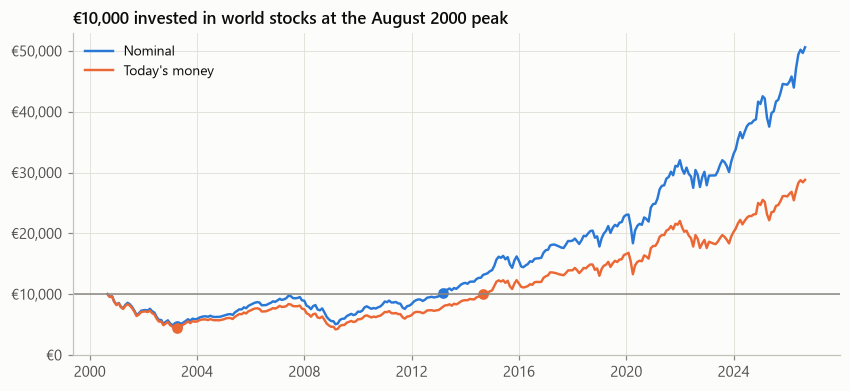

In [3]:
growth = (1 + long["world_equity"]).cumprod()
prices = (1 + long["inflation"]).cumprod()
peak = growth.loc[:"2001"].idxmax()
nominal = 10_000 * growth.loc[peak:] / growth[peak]
real = nominal / (prices.loc[peak:] / prices[peak])


def recovery(value):
    trough = value.loc[:"2004"].idxmin()
    return trough, value.loc[trough:][value.loc[trough:] >= 10_000].index[0]


fig, ax = plt.subplots(figsize=(9, 3.8))
for value, label, color in [(nominal, "Nominal", SERIES[0]), (real, "Today's money", SERIES[1])]:
    trough, recovered = recovery(value)
    ax.plot(value.index, value, color=color, label=label)
    ax.plot([trough, recovered], [value[trough], value[recovered]], "o", color=color, markersize=6)
ax.axhline(10_000, color=INK_MUTED, linewidth=1.0)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"€{v:,.0f}"))
ax.set_ylim(bottom=0)
ax.set_title("€10,000 invested in world stocks at the August 2000 peak")
ax.legend(loc="upper left")
fig.savefig(f"{FIGURES}/glance_crash.png")

pd.DataFrame(
    {
        label: {
            "lowest value": value[recovery(value)[0]],
            "lowest in": f"{recovery(value)[0]:%b %Y}",
            "back to €10,000 in": f"{recovery(value)[1]:%b %Y}",
            f"value in {value.index[-1]:%b %Y}": value.iloc[-1],
        }
        for label, value in [("nominal", nominal), ("today's money", real)]
    }
)

On the account statement the investment fell to €4,751 by March 2003 and was back at €10,000 in
February 2013. After inflation the recovery took until August 2014, fourteen years after the
peak. By 2026 it was worth about €50,600 on paper, or €28,800 in today's money. Anyone forced to
sell in 2003 lost half; anyone who could wait was rewarded.

## 3. Extreme days are far more common than a bell curve predicts

How often did the MSCI World ETF move by more than 3, 4 or 5 typical days since 2010? The second
column compares each day with the volatility of the whole period; the third with the volatility
of the weeks just before it (an exponentially weighted average).

In [4]:
prices_etf = universe.load_asset_prices(["EUNL.DE"])["EUNL.DE"].dropna()
daily = rt.simple_returns(prices_etf).loc["2009-12-31":].to_numpy()
years = len(daily) / 252
standardized = (daily - daily.mean()) / daily.std(ddof=1)
conditional = rt.ewma_standardize(daily)
rows = {}
for k in (3, 4, 5):
    expected = len(daily) * 2 * stats.norm.sf(k)
    rows[f"more than {k} sigma"] = {
        "days, whole-period volatility": int(np.sum(np.abs(standardized) > k)),
        "days, recent volatility": int(np.sum(np.abs(conditional) > k)),
        "bell curve expects (days)": round(expected, 3),
        "bell curve: once every ... years": round(years / expected, 1),
    }
pd.DataFrame(rows).T

,"days, whole-period volatility","days, recent volatility",bell curve expects (days),bell curve: once every ... years
more than 3 sigma,72.0,54.0,11.490,1.5
more than 4 sigma,24.0,26.0,0.270,62.6
more than 5 sigma,10.0,4.0,0.002,6921.7


A bell-curve model expects a 5-sigma day about once every 7,000 years; the ETF had 10 in 17 years.
Part of the effect is volatility clustering: calm and turbulent periods alternate, and a single
bell curve fitted to both misjudges each. Measured against the recent volatility, 4 such days
remain, still more than a thousand times what the bell curve expects. Both effects are real, and a
risk model that ignores either underestimates crashes.

## 4. Do bonds protect you when stocks fall?

,World stocks,10-year Bund
date,,
2002,-0.296,0.111
2008,-0.375,0.147
2022,-0.129,-0.223


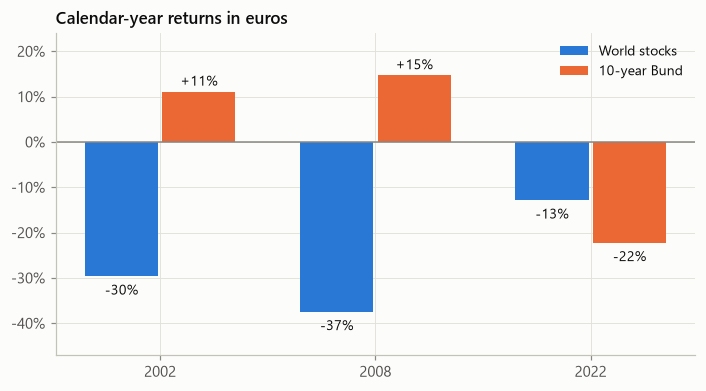

In [5]:
calendar = (1 + long[["world_equity", "bund_10y"]]).groupby(long.index.year).prod() - 1
years_shown = [2002, 2008, 2022]
table = calendar.loc[years_shown].rename(
    columns={"world_equity": "World stocks", "bund_10y": "10-year Bund"}
)
fig, ax = plt.subplots(figsize=(7.5, 3.8))
x = np.arange(len(years_shown))
for i, (column, color) in enumerate(zip(table.columns, SERIES[:2], strict=True)):
    bars = ax.bar(x + (i - 0.5) * 0.36, table[column], width=0.34, color=color, label=column)
    for bar, v in zip(bars, table[column], strict=True):
        ax.annotate(
            f"{v:+.0%}",
            (bar.get_x() + bar.get_width() / 2, v),
            xytext=(0, 4 if v > 0 else -12),
            textcoords="offset points",
            ha="center",
            fontsize=9,
            color=INK,
        )
ax.axhline(0, color=INK_MUTED, linewidth=1.0)
ax.set_xticks(x, [str(y) for y in years_shown])
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0%}"))
ax.set_ylim(-0.47, 0.24)
ax.set_title("Calendar-year returns in euros")
ax.legend(loc="upper right")
fig.savefig(f"{FIGURES}/glance_bonds.png")
table.round(3)

In 2002 and 2008 German government bonds gained while world stocks lost 30% and 37%, cushioning
a mixed portfolio. In 2022 both fell, stocks by 13% and bonds by 22%: rising inflation pushed
interest rates up, and rising rates lower bond prices. In this sample bonds protected against
recessions but not against inflation. Three years are an illustration, not a law.

## 5. Spreading the risk

One German stock (average)    0.265
Five German stocks            0.195
World index (MSCI World)      0.124
dtype: float64

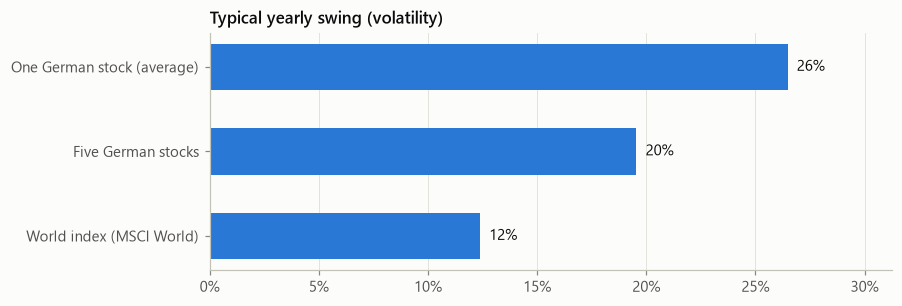

In [6]:
returns = universe.load_asset_returns()
stocks = returns[universe.MODEL_PORTFOLIOS["concentrated"].tickers]
vols = pd.Series(
    {
        "One German stock (average)": (stocks.std() * np.sqrt(12)).mean(),
        "Five German stocks": stocks.mean(axis=1).std() * np.sqrt(12),
        "World index (MSCI World)": returns["EUNL.DE"].std() * np.sqrt(12),
    }
)
fig, ax = plt.subplots(figsize=(8, 2.8))
ax.barh(vols.index[::-1], vols.to_numpy()[::-1], color=SERIES[0], height=0.55)
for i, v in enumerate(vols.to_numpy()[::-1]):
    ax.annotate(
        f"{v:.0%}",
        (v, i),
        xytext=(6, 0),
        textcoords="offset points",
        va="center",
        fontsize=10,
        color=INK,
    )
ax.set_xlim(0, vols.max() * 1.18)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0%}"))
ax.grid(axis="y", visible=False)
ax.set_title("Typical yearly swing (volatility)")
fig.savefig(f"{FIGURES}/glance_diversification.png")
vols.round(3)

A single German blue-chip stock typically swings about 26% in a year. Five of them together swing
about 20%: the companies share one economy, so their moves partly coincide. The world index swings
about 12%. Diversification pays most when the holdings are genuinely different.

## 6. How much can a retiree withdraw?

Retire with €500,000 in a 60/40 portfolio and withdraw a fixed amount each year, raised with
inflation, for 30 years (tax-free account, 0.2% fund costs). Each square is one of 100 simulated
histories.

4%    0.838
3%    0.967
Name: share of histories that last 30 years, dtype: float64

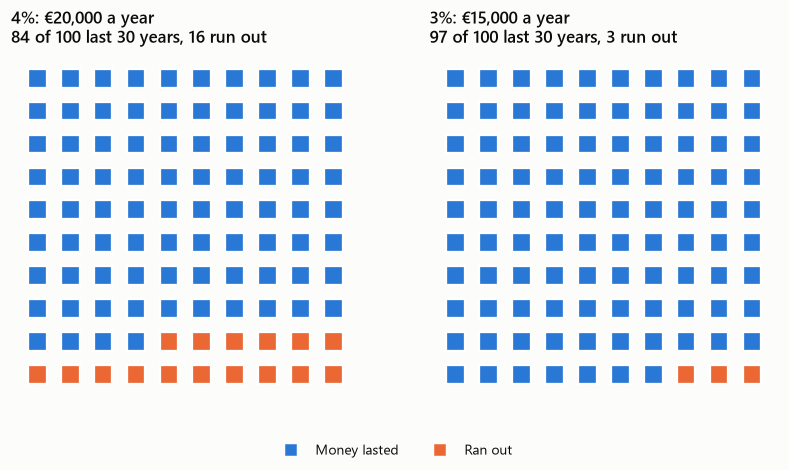

In [7]:
model = mc.Bootstrap(balanced, long["inflation"], mean_block=12)
outcomes = {}
for rate in (0.04, 0.03):
    p = mc.SavingsPlan(
        initial=500_000,
        monthly_contribution=0,
        accumulation_years=0,
        withdrawal_years=30,
        withdrawal_rate=rate,
        annual_fee=0.002,
    )
    outcomes[rate] = mc.simulate(model, p, n_paths=10_000, seed=2).success_rate()

fig, axes = plt.subplots(1, 2, figsize=(9, 4.4))
for ax, (rate, success) in zip(axes, outcomes.items(), strict=True):
    lasted = round(success * 100)
    colors = [SERIES[0]] * lasted + [SERIES[1]] * (100 - lasted)
    xs, ys = np.meshgrid(np.arange(10), np.arange(10)[::-1])
    ax.scatter(
        xs.ravel(), ys.ravel(), s=150, marker="s", color=colors, edgecolor="white", linewidth=1.5
    )
    ax.set_xlim(-0.8, 9.8)
    ax.set_ylim(-0.8, 9.8)
    ax.set_aspect("equal")
    ax.axis("off")
    ax.set_title(
        f"{rate:.0%}: €{500_000 * rate:,.0f} a year\n"
        f"{lasted} of 100 last 30 years, {100 - lasted} run out"
    )
fig.legend(
    handles=[
        plt.Line2D([], [], marker="s", linestyle="", color=SERIES[0], label="Money lasted"),
        plt.Line2D([], [], marker="s", linestyle="", color=SERIES[1], label="Ran out"),
    ],
    loc="lower center",
    ncols=2,
)
fig.savefig(f"{FIGURES}/glance_withdrawals.png")
pd.Series(
    {f"{r:.0%}": s for r, s in outcomes.items()}, name="share of histories that last 30 years"
)

Withdrawing €20,000 a year (4%) ran out of money in 16 of 100 histories; €15,000 a year (3%) in 3.
The well-known 4% rule was derived from US market history. With euro-area returns since 1999 and
realistic fund costs, it is noticeably riskier.

## 7. How much do these numbers depend on the past?

Every result above reuses one 27-year history, in which the 60/40 portfolio earned about 6% a
year. The same simulations with 1 and 2 percentage points less return per year:

In [8]:
rows = {}
for cut in (0.0, 0.01, 0.02):
    m = mc.Bootstrap(balanced, long["inflation"], mean_block=12, return_adjustment=-cut / 12)
    saver = mc.simulate(m, plan, n_paths=10_000, seed=1).terminal(after_tax=True)
    lasts = {}
    for rate in (0.04, 0.03):
        p = mc.SavingsPlan(
            initial=500_000,
            monthly_contribution=0,
            accumulation_years=0,
            withdrawal_years=30,
            withdrawal_rate=rate,
            annual_fee=0.002,
        )
        lasts[rate] = mc.simulate(m, p, n_paths=10_000, seed=2).success_rate()
    rows[f"history {-cut:+.0%} a year" if cut else "history as it was"] = {
        "savings plan: median after tax": round(np.median(saver), -3),
        "savings plan: 5th percentile": round(np.percentile(saver, 5), -3),
        "4% withdrawals: last 30 years (of 100)": round(lasts[0.04] * 100),
        "3% withdrawals: last 30 years (of 100)": round(lasts[0.03] * 100),
    }
pd.DataFrame(rows).T

,savings plan: median after tax,savings plan: 5th percentile,4% withdrawals: last 30 years (of 100),3% withdrawals: last 30 years (of 100)
history as it was,289000.0,170000.0,84.0,97.0
history -1% a year,248000.0,150000.0,71.0,92.0
history -2% a year,215000.0,132000.0,55.0,84.0


One percentage point less return a year lowers the median savings result by about 14% and cuts
the 4% rule's success from 84 to 71 histories in 100. The headline numbers are one plausible
scenario built from one history, not a forecast.

## 8. Skill or luck?

In [9]:
assets = long[["world_equity", "bund_10y", "cash"]]
trend = bt.run_backtest(
    assets, bt.TrendFollowing({"world_equity": 1.0}), bt.Rebalance(every=1), start=36
)
hold = bt.run_backtest(
    assets, bt.FixedWeights({"world_equity": 1.0}), bt.Rebalance(every=12), start=36
)
reshuffled = bt.bootstrap_difference(trend.returns, hold.returns, n_boot=2000)
pd.DataFrame(
    {
        "trend following": {
            "€1 grew to": trend.wealth.iloc[-1],
            "worst drawdown": risk.max_drawdown(trend.returns),
            "traded per year (share of portfolio)": trend.turnover.mean() * 12,
        },
        "buy and hold": {
            "€1 grew to": hold.wealth.iloc[-1],
            "worst drawdown": risk.max_drawdown(hold.returns),
            "traded per year (share of portfolio)": hold.turnover.mean() * 12,
        },
    }
).round(2)

,trend following,buy and hold
€1 grew to,8.01,6.84
worst drawdown,0.20,0.48
traded per year (share of portfolio),3.21,0.04


A simple trend-following rule (hold stocks only while they trade above their 10-month average)
turned €1 into €8.0 since 2002, against €6.8 for buying and holding, and its worst fall was 20%
instead of 48%. Resampling the history 2,000 times, it came out behind in about 9 cases out of
100: suggestive, but not enough to rule out luck. The comparison also ignores taxes. The rule
trades about three times the portfolio each year, and in a taxable German account each sale
realises gains, so part of the advantage would go to tax.

## Where each number comes from

| Result | Notebook |
|---|---|
| Savings plan, withdrawals, sensitivity | [7. Monte Carlo](07_montecarlo.ipynb) |
| Crash and recovery | [3. Risk](03_risk.ipynb) |
| Extreme days | [2. Returns](02_returns.ipynb) |
| Bonds as protection, spreading risk | [4. Diversification](04_diversification.ipynb) |
| Skill or luck | [6. Backtest](06_backtest.ipynb) |
| How the simulations are checked | [8. Validation](08_validation.ipynb) |